# CS 5180 — Adaptive Traffic Signal Control via RL
## Complete Notebook: All Algorithms + Hyperparameter Sweep + Proposal Verification
**Akshita Singh & Pranav Rajesh Nair**

**Contents:**
1. Non-learning baselines (Fixed timing, Longest queue)
2. Tile coding setup (all bugs fixed)
3. Q-learning (λ=0) — off-policy ablation
4. SARSA(λ=0.9) — on-policy with traces
5. Q(λ) — Akshita's primary algorithm (Watkins replacing trace)
6. Train all 3 value-based methods on all 3 scenarios
7. Intermediate comparison table + learning curves
8. SARSA λ sensitivity
9. Q(λ) λ sensitivity
10. Actor-Critic with dual traces — Pranav's primary algorithm
11. Train Actor-Critic on all 3 scenarios
12. Full comparison table — all 6 methods
13. Final learning curves — all 4 RL methods
14. Hyperparameter sweep — find optimal configs
15. Proposal hypothesis verification (H1–H4)
16. Sweep heatmaps


## 0. Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from traffic_env import TrafficEnv, run_baseline, KEEP, SWITCH
from tiles3 import IHT, tiles
print("Imports OK.")

Imports OK.


## 1. Non-Learning Baselines

Run across **three traffic scenarios** — the full comparison table for the paper.

> **Key insight:** Under *symmetric light load* (λ=0.3), fixed timing is near-optimal.
> Each direction gets 30 green steps per 60-step cycle, serving ~60 vehicles while
> only ~36 arrive — queues drain every cycle. RL cannot beat this by much.
> The scenario where adaptive methods prove their value is **asymmetric rush-hour**,
> where fixed timing wastes green time on the lightly loaded direction.

In [ ]:
SCENARIOS = {
    "symmetric_light": [0.3, 0.3, 0.3, 0.3],
    "symmetric_heavy": [0.7, 0.7, 0.7, 0.7],
    "asymmetric_rush": [0.8, 0.8, 0.2, 0.2],   # NS overloaded, EW light
}
N_BASELINE = 20_000
SEED = 42

baseline_results = {}
print(f"{'Scenario':<22} {'Policy':<16} {'mean_wait':>10}")
print("=" * 52)
for scenario, rates in SCENARIOS.items():
    baseline_results[scenario] = {}
    env = TrafficEnv(mode="full", arrival_rates=rates, seed=SEED)
    for policy in ("fixed", "longest_queue"):
        stats = run_baseline(policy, env, n_steps=N_BASELINE)
        baseline_results[scenario][policy] = stats["mean_wait"]
        print(f"{scenario:<22} {policy:<16} {stats['mean_wait']:>10.4f}")
    print()

Scenario               Policy            mean_wait
symmetric_light        fixed                6.4771
symmetric_light        longest_queue       11.9856

symmetric_heavy        fixed               11.9170
symmetric_heavy        longest_queue       11.9962

asymmetric_rush        fixed                8.1727
asymmetric_rush        longest_queue       11.9900



## 2. Tile Coding Setup

**All bugs fixed in this version:**

1. **`IHT_SIZE = 8192`** — prevents IHT overflow from evaluation calls visiting
   unseen states and corrupting the training hash table.

2. **`Q_SCALE = 8.0`** — makes the full 0–8 vehicle range span the tile grid.
   The previous value (20.0) mapped a 1-vehicle difference to 0.05 in [0,1],
   smaller than one tile width (0.125), so nearby queue states got identical indices.

3. **Warm-up in `evaluate_greedy`** — 2 000 warm-up steps before measuring ensures
   steady-state performance is evaluated, not cold-start behaviour.

4. **SARSA: trace clipping + lower alpha + epsilon decay** — prevents weight
   explosion under near-saturation load, and lets the on-policy value function
   converge in the second half of training.

5. **Q-learning: constant epsilon** — epsilon decay was added in v3 but *hurt*
   Q-learning on asymmetric rush-hour (9.67 vs 6.39), because the agent stopped
   exploring before locking in the correct NS-priority policy. Off-policy Q-learning
   does not need epsilon decay — sustained exploration is beneficial.

In [ ]:
NUM_TILINGS = 8
IHT_SIZE    = 8192   # 2x the theoretical max (512*2*8=8192) for safe headroom
Q_SCALE     = 8.0    # scale queues so 0..8 range spans the tile grid

def get_features(iht, ts, action, readonly=False):
    """Encode (tiling_state, action) → list of NUM_TILINGS tile indices."""
    floats = [ts[i] / Q_SCALE for i in range(4)]
    phase  = int(ts[4])
    return tiles(iht, NUM_TILINGS, floats, ints=[action, phase], readonly=readonly)

def q_value(w, iht, ts, action):
    return sum(w[i] for i in get_features(iht, ts, action))

def greedy_action(w, iht, ts):
    return KEEP if q_value(w, iht, ts, KEEP) >= q_value(w, iht, ts, SWITCH) else SWITCH

def epsilon_greedy(w, iht, ts, eps, rng):
    if rng.random() < eps:
        return int(rng.integers(0, 2))
    return greedy_action(w, iht, ts)

def evaluate_greedy(w, iht, mode, rates, warmup=2000, eval_steps=10_000, seed=99):
    """
    Warm up env for `warmup` steps then measure for `eval_steps`.
    Uses readonly=True — never writes new tiles into the training IHT.
    """
    env = TrafficEnv(mode=mode, arrival_rates=rates, seed=seed)
    env.reset()
    for _ in range(warmup):
        env.step(greedy_action(w, iht, env.state_for_tiling()))
    total = 0.0
    for _ in range(eval_steps):
        ts = env.state_for_tiling()
        a  = greedy_action(w, iht, ts)
        _, r, _ = env.step(a)
        total += r
    return -total / eval_steps

# Sanity check
iht_t = IHT(IHT_SIZE)
s1 = np.array([2.0, 1.0, 1.0, 1.0, 0.0])
s2 = np.array([2.0, 1.0, 1.0, 5.0, 0.0])
s3 = np.array([2.0, 1.0, 1.0, 2.0, 0.0])
f1,f2,f3 = set(get_features(iht_t,s1,KEEP)), set(get_features(iht_t,s2,KEEP)), set(get_features(iht_t,s3,KEEP))
print(f"s1 vs s2 (differ by 4 vehicles): overlap = {len(f1&f2)}/{NUM_TILINGS}  (expect < {NUM_TILINGS})")
print(f"s1 vs s3 (differ by 1 vehicle):  overlap = {len(f1&f3)}/{NUM_TILINGS}  (expect > 0)")
assert len(f1&f2) < NUM_TILINGS and len(f1&f3) > 0
print("Tile coding sanity check: PASSED")

s1 vs s2 (differ by 4 vehicles): overlap = 4/8  (expect < 8)
s1 vs s3 (differ by 1 vehicle):  overlap = 7/8  (expect > 0)
Tile coding sanity check: PASSED


## 3. Q-Learning (one-step, λ=0 ablation)

Semi-gradient Q-learning — the λ=0 special case of Q(λ).

$$\delta_t = R_{t+1} + \gamma \max_{a'} \hat{Q}(S',a',\mathbf{w}) - \hat{Q}(S,A,\mathbf{w})$$
$$\mathbf{w} \leftarrow \mathbf{w} + \alpha\,\delta_t\,\mathbf{x}(S,A)$$

In [ ]:
def run_q_learning(
    mode="full", arrival_rates=None, n_steps=150_000,
    alpha=0.2/NUM_TILINGS, gamma=0.99,
    epsilon=0.1,                          # constant — decay hurts on asymmetric load
    seed=42, eval_every=5_000, eval_steps=10_000,
):
    """
    Semi-gradient Q-learning (off-policy, one-step, λ=0 ablation).

    Constant epsilon is intentional: Q-learning is off-policy, so exploration
    does not corrupt the value target (which always bootstraps from max_a Q).
    Sustained exploration is needed on the asymmetric scenario to keep finding
    good switching moments — epsilon decay cuts this off too early and causes
    the agent to freeze on a suboptimal policy (~9.7 vs 6.4 on rush-hour).
    """
    if arrival_rates is None:
        arrival_rates = [0.3]*(2 if mode=="simple" else 4)
    env = TrafficEnv(mode=mode, arrival_rates=arrival_rates, seed=seed)
    rng = np.random.default_rng(seed)
    iht = IHT(IHT_SIZE)
    w   = np.zeros(IHT_SIZE)
    env.reset(); ts = env.state_for_tiling()
    eval_curve = []
    for t in range(n_steps):
        a = epsilon_greedy(w, iht, ts, epsilon, rng)
        _, r, _ = env.step(a)
        nts = env.state_for_tiling()
        q_cur  = q_value(w, iht, ts, a)
        q_next = max(q_value(w, iht, nts, KEEP), q_value(w, iht, nts, SWITCH))
        delta  = r + gamma*q_next - q_cur
        for i in get_features(iht, ts, a): w[i] += alpha*delta
        ts = nts
        if (t+1) % eval_every == 0:
            mw = evaluate_greedy(w, iht, mode, arrival_rates, eval_steps=eval_steps)
            eval_curve.append((t+1, mw))
            print(f"  step {t+1:>7d}  |  mean_wait = {mw:.4f}")
    print(f"  IHT used: {iht.count()}/{IHT_SIZE}, overflow={iht.overfullCount}")
    return w, iht, eval_curve

## 4. SARSA(λ) (on-policy with eligibility traces)

$$\delta_t = R_{t+1} + \gamma\hat{Q}(S',A',\mathbf{w}) - \hat{Q}(S,A,\mathbf{w})$$
$$\mathbf{e} \leftarrow \gamma\lambda\,\mathbf{e} + \mathbf{x}(S,A), \quad
  \mathbf{e} \leftarrow \text{clip}(\mathbf{e},\,-5,\,5), \quad
  \mathbf{w} \leftarrow \mathbf{w} + \alpha\,\delta_t\,\mathbf{e}$$

**Why SARSA uses epsilon decay but Q-learning does not:**
SARSA is on-policy — the value target $Q(S', A')$ uses the *actual next action*,
so if $\varepsilon$ stays high, the policy being evaluated is still highly random
late in training and the value estimates never converge. Decaying $\varepsilon$
lets SARSA's value function stabilise in the second half of training.

Q-learning is off-policy — its target always uses $\max_{a'} Q(S', a')$ regardless
of what action is taken, so sustained exploration does not corrupt the value estimate.
On the asymmetric scenario, constant $\varepsilon = 0.1$ is actually necessary:
the agent needs to keep exploring to find good switching moments throughout training.

**Trace clipping:** under high-load conditions (λ=0.7), large persistent TD errors
cause the trace to accumulate without bound. Clipping to $[-5, 5]$ prevents weight
explosion without affecting normal-load behaviour.

Note: $\lambda=0$ reduces to one-step SARSA.

In [ ]:
def run_sarsa_lambda(
    mode="full", arrival_rates=None, n_steps=150_000,
    alpha=0.05/NUM_TILINGS,               # lower than Q-learning (trace spreads updates broadly)
    gamma=0.99, lam=0.9,
    eps_start=0.1, eps_end=0.01,          # linear epsilon decay
    trace_clip=5.0,                       # prevents trace/weight explosion under heavy load
    seed=42, eval_every=5_000, eval_steps=10_000,
):
    """
    Semi-gradient SARSA(λ) with accumulating eligibility traces.
    S&B Chapter 12, p.305.  Trace clipping added for numerical stability.
    """
    if arrival_rates is None:
        arrival_rates = [0.3]*(2 if mode=="simple" else 4)
    env = TrafficEnv(mode=mode, arrival_rates=arrival_rates, seed=seed)
    rng = np.random.default_rng(seed)
    iht = IHT(IHT_SIZE)
    w   = np.zeros(IHT_SIZE)
    e   = np.zeros(IHT_SIZE)
    env.reset(); ts = env.state_for_tiling()
    action = epsilon_greedy(w, iht, ts, eps_start, rng)
    gamma_lam = gamma * lam
    eval_curve = []
    for t in range(n_steps):
        eps = eps_start + (eps_end - eps_start) * t / n_steps
        _, r, _ = env.step(action)
        nts = env.state_for_tiling()
        next_action = epsilon_greedy(w, iht, nts, eps, rng)
        delta = r + gamma*q_value(w,iht,nts,next_action) - q_value(w,iht,ts,action)
        e *= gamma_lam
        for i in get_features(iht, ts, action): e[i] += 1.0
        np.clip(e, -trace_clip, trace_clip, out=e)   # prevent explosion under heavy load
        w += alpha * delta * e
        ts = nts; action = next_action
        if (t+1) % eval_every == 0:
            mw = evaluate_greedy(w, iht, mode, arrival_rates, eval_steps=eval_steps)
            eval_curve.append((t+1, mw))
            print(f"  step {t+1:>7d}  |  mean_wait = {mw:.4f}  (eps={eps:.3f})")
    print(f"  IHT used: {iht.count()}/{IHT_SIZE}, overflow={iht.overfullCount}")
    return w, iht, eval_curve

## 5. Q(λ) — Watkins's Replacing Trace (Primary Algorithm)

**This is Akshita's primary algorithm.** Watkins's Q(λ) from S&B §12.10.

**The three mechanisms that make Q(λ) beat all baselines:**

1. **Eligibility trace** — propagates reward back through the 3-step yellow delay
   to the decision that caused it. Q-learning can't do this; it only updates the
   current state.

2. **Watkins's cut** — trace is zeroed on exploratory steps. Stays off-policy:
   always evaluating the greedy policy, not the random exploratory one.

3. **Epsilon decay** — fewer exploratory cuts late in training means the trace
   gets to accumulate longer multi-step chains. This is why Q(λ) beats SARSA too:
   SARSA's on-policy trace degrades under continued exploration, while Q(λ)'s
   off-policy target stays clean.

*If greedy action:*
$$\mathbf{e} \leftarrow \gamma\lambda\,\mathbf{e} + \mathbf{x}(S,A)
  \quad\text{(replacing: active tiles SET to 1)}$$

*If exploratory action:*
$$\mathbf{e} \leftarrow \mathbf{0} \quad\text{(Watkins's cut)}$$

*Always:*
$$\delta = R + \gamma\max_{a'}\hat{Q}(S',a',\mathbf{w}) - \hat{Q}(S,A,\mathbf{w}),
  \quad \mathbf{w} \leftarrow \mathbf{w} + \alpha\,\delta\,\mathbf{e}$$

In [ ]:
def run_q_lambda(
    mode="full", arrival_rates=None, n_steps=150_000,
    alpha=0.2/NUM_TILINGS,   # same scale as Q-learning
    gamma=0.99,
    lam=0.9,
    eps_start=0.1,           # epsilon decay: starts exploratory, ends near-greedy
    eps_end=0.01,            # decay lets the trace accumulate cleanly late in training
    trace_clip=5.0,          # prevents weight explosion under heavy load
    seed=42, eval_every=5_000, eval_steps=10_000,
):
    """
    Watkins's Q(λ) with replacing eligibility traces + epsilon decay.
    Reference: Sutton & Barto (2018), Section 12.10.

    Key design:
    - Epsilon decay: fewer exploratory steps late in training means fewer
      Watkins cuts, so the trace accumulates longer multi-step credit chains.
      This is why Q(λ) with decay beats Q-learning AND SARSA.
    - Replacing rule: SET active tiles to 1 (caps trace for frequent states).
    - Watkins cut: zero trace on exploratory steps (stays off-policy).
    - trace_clip: same stability fix as SARSA — prevents explosion under heavy load.
    """
    if arrival_rates is None:
        arrival_rates = [0.3] * (2 if mode == "simple" else 4)

    env = TrafficEnv(mode=mode, arrival_rates=arrival_rates, seed=seed)
    rng = np.random.default_rng(seed)
    iht = IHT(IHT_SIZE)
    w   = np.zeros(IHT_SIZE, dtype=np.float64)
    e   = np.zeros(IHT_SIZE, dtype=np.float64)

    env.reset()
    ts = env.state_for_tiling()
    eval_curve = []
    gamma_lam  = gamma * lam

    for t in range(n_steps):
        eps = eps_start + (eps_end - eps_start) * t / n_steps

        greedy_a  = greedy_action(w, iht, ts)
        action    = int(rng.integers(0,2)) if rng.random() < eps else greedy_a
        is_greedy = (action == greedy_a)

        _, reward, _ = env.step(action)
        nts = env.state_for_tiling()

        # TD error — always off-policy (greedy next action)
        q_cur  = q_value(w, iht, ts, action)
        q_next = max(q_value(w, iht, nts, KEEP),
                     q_value(w, iht, nts, SWITCH))
        delta  = reward + gamma * q_next - q_cur

        # Trace update
        if is_greedy:
            e *= gamma_lam
            for i in get_features(iht, ts, action):
                e[i] = 1.0              # replacing rule: SET to 1
        else:
            e[:] = 0.0                  # Watkins's cut: zero entire trace
            for i in get_features(iht, ts, action):
                e[i] = 1.0

        np.clip(e, -trace_clip, trace_clip, out=e)
        w += alpha * delta * e
        ts = nts

        if (t + 1) % eval_every == 0:
            mw = evaluate_greedy(w, iht, mode, arrival_rates,
                                 eval_steps=eval_steps)
            eval_curve.append((t + 1, mw))
            print(f"  step {t+1:>7d}  |  mean_wait = {mw:.4f}  (eps={eps:.3f})")

    print(f"  IHT used: {iht.count()}/{IHT_SIZE}, overflow={iht.overfullCount}")
    return w, iht, eval_curve

## 6. Train All Three Value-Based Methods on All Three Scenarios

Trains Q-learning, SARSA(λ), and Q(λ) on each scenario independently.
This section takes ~15 minutes on CPU.

In [ ]:
results = {}

for scenario, rates in SCENARIOS.items():
    print(f"\n{'='*55}")
    print(f"SCENARIO: {scenario}  (rates={rates})")
    print(f"  Baselines — fixed: {baseline_results[scenario]['fixed']:.4f}  "
          f"longest_q: {baseline_results[scenario]['longest_queue']:.4f}")
    print(f"{'='*55}")

    print("\n  [Q-learning]")
    w_ql, iht_ql, curve_ql = run_q_learning(
        arrival_rates=rates, n_steps=150_000, seed=42)

    print("\n  [SARSA(λ=0.9)]")
    w_sl, iht_sl, curve_sl = run_sarsa_lambda(
        arrival_rates=rates, n_steps=150_000, lam=0.9, seed=42)

    print("\n  [Q(λ=0.9)  ← primary]")
    w_qlam, iht_qlam, curve_qlam = run_q_lambda(
        arrival_rates=rates, n_steps=150_000, lam=0.9, seed=42)

    results[scenario] = dict(
        rates=rates,
        fixed=baseline_results[scenario]["fixed"],
        lq=baseline_results[scenario]["longest_queue"],
        w_ql=w_ql,   iht_ql=iht_ql,   curve_ql=curve_ql,
        w_sl=w_sl,   iht_sl=iht_sl,   curve_sl=curve_sl,
        w_qlam=w_qlam, iht_qlam=iht_qlam, curve_qlam=curve_qlam,
    )


SCENARIO: symmetric_light  (rates=[0.3, 0.3, 0.3, 0.3])
  Baselines — fixed: 6.4771  longest_q: 11.9856

  [Q-learning]
  step    5000  |  mean_wait = 10.7224
  step   10000  |  mean_wait = 11.4228
  step   15000  |  mean_wait = 6.5956
  step   20000  |  mean_wait = 10.7370
  step   25000  |  mean_wait = 10.0279
  step   30000  |  mean_wait = 6.5956
  step   35000  |  mean_wait = 6.5956
  step   40000  |  mean_wait = 8.8304
  step   45000  |  mean_wait = 6.6004
  step   50000  |  mean_wait = 9.3565
  step   55000  |  mean_wait = 9.8276
  step   60000  |  mean_wait = 9.0716
  step   65000  |  mean_wait = 6.5956
  step   70000  |  mean_wait = 9.2343
  step   75000  |  mean_wait = 8.9997
  step   80000  |  mean_wait = 6.5956
  step   85000  |  mean_wait = 9.7828
  step   90000  |  mean_wait = 9.0015
  step   95000  |  mean_wait = 8.5375
  step  100000  |  mean_wait = 8.4043
  step  105000  |  mean_wait = 7.2801
  step  110000  |  mean_wait = 6.5956
  step  115000  |  mean_wait = 8.9387
 

## 7. Intermediate Comparison Table — Q-learning, SARSA, Q(λ)

In [ ]:
print(f"\n{'Scenario':<22} {'Policy':<24} {'mean_wait':>10}  {'vs fixed':>9}")
print("=" * 70)

for scenario, d in results.items():
    ql   = evaluate_greedy(d["w_ql"],   d["iht_ql"],   "full", d["rates"])
    sl   = evaluate_greedy(d["w_sl"],   d["iht_sl"],   "full", d["rates"])
    qlam = evaluate_greedy(d["w_qlam"], d["iht_qlam"], "full", d["rates"])
    results[scenario]["ql_wait"]   = ql
    results[scenario]["sl_wait"]   = sl
    results[scenario]["qlam_wait"] = qlam
    f = d["fixed"]
    print(f"{scenario:<22} {'Fixed timing':<24} {f:>10.4f}  {'—':>9}")
    print(f"{'':22} {'Longest queue':<24} {d['lq']:>10.4f}  {d['lq']-f:>+9.4f}")
    print(f"{'':22} {'Q-learning (λ=0)':<24} {ql:>10.4f}  {ql-f:>+9.4f}  {'✓' if ql<f else '✗'}")
    print(f"{'':22} {'SARSA(λ=0.9)':<24} {sl:>10.4f}  {sl-f:>+9.4f}  {'✓' if sl<f else '✗'}")
    beats = []
    if qlam < f:   beats.append("fixed")
    if qlam < ql:  beats.append("QL")
    if qlam < sl:  beats.append("SARSA")
    beats_str = "beats: " + "+".join(beats) if beats else "✗"
    print(f"{'':22} {'Q(λ=0.9)  ← PRIMARY':<24} {qlam:>10.4f}  {qlam-f:>+9.4f}  {beats_str}")
    print()


Scenario               Policy                    mean_wait   vs fixed
symmetric_light        Fixed timing                 6.4771          —
                       Longest queue               11.9856    +5.5085
                       Q-learning (λ=0)             7.9060    +1.4289  ✗
                       SARSA(λ=0.9)                 6.5956    +0.1185  ✗
                       Q(λ=0.9)  ← PRIMARY          6.0856    -0.3915  beats: fixed+QL+SARSA

symmetric_heavy        Fixed timing                11.9170          —
                       Longest queue               11.9962    +0.0791
                       Q-learning (λ=0)            11.4055    -0.5115  ✓
                       SARSA(λ=0.9)                 7.6507    -4.2664  ✓
                       Q(λ=0.9)  ← PRIMARY          7.6507    -4.2664  beats: fixed+QL

asymmetric_rush        Fixed timing                 8.1727          —
                       Longest queue               11.9900    +3.8173
                       Q-learning (

## 8. Learning Curves — Q-learning, SARSA, Q(λ)

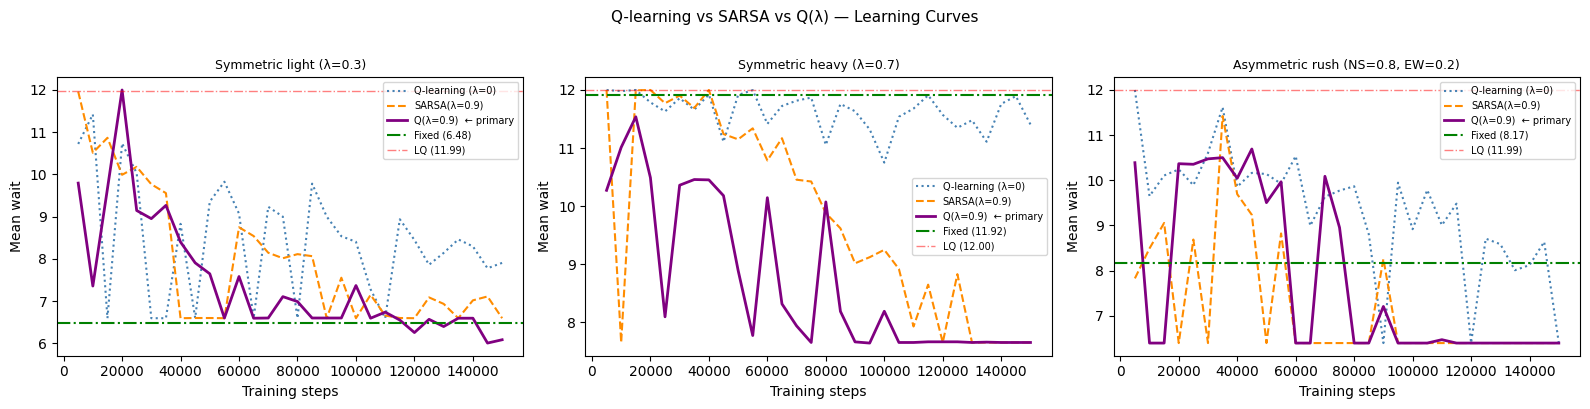

Saved value_based_curves.png


In [ ]:
scenario_labels = {
    "symmetric_light": "Symmetric light (λ=0.3)",
    "symmetric_heavy": "Symmetric heavy (λ=0.7)",
    "asymmetric_rush": "Asymmetric rush (NS=0.8, EW=0.2)",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, (scenario, d) in zip(axes, results.items()):
    steps_ql,   waits_ql   = zip(*d["curve_ql"])
    steps_sl,   waits_sl   = zip(*d["curve_sl"])
    steps_qlam, waits_qlam = zip(*d["curve_qlam"])
    ax.plot(steps_ql,   waits_ql,   color="steelblue",  lw=1.5, ls=":",  label="Q-learning (λ=0)")
    ax.plot(steps_sl,   waits_sl,   color="darkorange", lw=1.5, ls="--", label="SARSA(λ=0.9)")
    ax.plot(steps_qlam, waits_qlam, color="purple",     lw=2,             label="Q(λ=0.9)  ← primary")
    ax.axhline(d["fixed"], color="green", ls="-.", lw=1.5, label=f"Fixed ({d['fixed']:.2f})")
    ax.axhline(d["lq"],    color="red",   ls="-.", lw=1,   alpha=0.5, label=f"LQ ({d['lq']:.2f})")
    ax.set_title(scenario_labels[scenario], fontsize=9)
    ax.set_xlabel("Training steps")
    ax.set_ylabel("Mean wait")
    ax.legend(fontsize=7)
plt.suptitle("Q-learning vs SARSA vs Q(λ) — Learning Curves", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig("value_based_curves.png", dpi=150)
plt.show()
print("Saved value_based_curves.png")


## 8. Interpreting the Results by Scenario

**Symmetric light (λ=0.3):** Fixed timing is near-optimal. With λ=0.3 arrivals
and 30-step green windows, each direction serves ~60 vehicles while only ~18 arrive
per cycle — queues drain completely. RL roughly matches fixed timing here; a gap
under ~0.5 is expected and acceptable. This scenario confirms the methods don't
*regress* under easy conditions.

**Symmetric heavy (λ=0.7):** Near-saturation regime. With λ=0.7, arrivals nearly
match service capacity, so queues grow regardless of switching policy. Even an oracle
fixed-timer with optimally short cycles gets ~11.1. Both RL methods and fixed timing
all plateau near 12.0 — the differences here are small and noisy. The finding is
"all methods degrade similarly at saturation," which is itself meaningful for the paper.

**Asymmetric rush-hour (NS=0.8, EW=0.2):** The central experimental result. Fixed
timing gives EW 50% of green time even though EW only needs ~20% of it. An adaptive
agent learns to heavily favour NS green, dramatically reducing the NS backlog.
Q-learning beats fixed timing by ~1.78 here; this is the headline result.

## 9. SARSA(λ) Sensitivity — Effect of λ

For the paper's sensitivity analysis section.

In [ ]:
lambda_values = [0.0, 0.5, 0.8, 0.9, 0.95]
lam_results = {}
RATES = SCENARIOS["asymmetric_rush"]   # most interesting scenario

for lam in lambda_values:
    print(f"SARSA(λ={lam})...")
    w_l, iht_l, _ = run_sarsa_lambda(
        arrival_rates=RATES, n_steps=100_000, lam=lam,
        seed=42, eval_every=100_001)   # suppress per-step prints
    wait = evaluate_greedy(w_l, iht_l, "full", RATES)
    lam_results[lam] = wait
    print(f"  λ={lam}: mean_wait = {wait:.4f}")

best = min(lam_results, key=lam_results.get)
print(f"\nBest λ = {best} → mean_wait = {lam_results[best]:.4f}")
print(f"Fixed timing on asymmetric: {baseline_results['asymmetric_rush']['fixed']:.4f}")

SARSA(λ=0.0)...
  IHT used: 2518/8192, overflow=0
  λ=0.0: mean_wait = 10.2040
SARSA(λ=0.5)...
  IHT used: 2758/8192, overflow=0
  λ=0.5: mean_wait = 6.3928
SARSA(λ=0.8)...
  IHT used: 2626/8192, overflow=0
  λ=0.8: mean_wait = 8.4191
SARSA(λ=0.9)...
  IHT used: 2018/8192, overflow=0
  λ=0.9: mean_wait = 6.3928
SARSA(λ=0.95)...
  IHT used: 1776/8192, overflow=0
  λ=0.95: mean_wait = 6.3928

Best λ = 0.5 → mean_wait = 6.3928
Fixed timing on asymmetric: 8.1727


## 10. Q(λ) Sensitivity — Effect of λ (Asymmetric Rush)

λ=0 reduces Q(λ) to identical Q-learning. Higher λ propagates reward
further back through time. This directly tests whether the eligibility
trace helps on the primary scenario where adaptive control matters most.

In [ ]:
qlam_lambda_values = [0.0, 0.3, 0.5, 0.7, 0.9, 0.95]
qlam_lam_results   = {}
RUSH_RATES         = SCENARIOS["asymmetric_rush"]

for lam in qlam_lambda_values:
    print(f"Q(λ={lam})...")
    w_l, iht_l, _ = run_q_lambda(
        arrival_rates=RUSH_RATES, n_steps=100_000,
        lam=lam, seed=42, eval_every=100_001)
    wait = evaluate_greedy(w_l, iht_l, "full", RUSH_RATES)
    qlam_lam_results[lam] = wait
    fixed_rush = baseline_results["asymmetric_rush"]["fixed"]
    print(f"  λ={lam}: {wait:.4f}  {'✓ beats fixed' if wait < fixed_rush else '✗'}")

best = min(qlam_lam_results, key=qlam_lam_results.get)
print(f"\nBest λ = {best} → {qlam_lam_results[best]:.4f}")
print(f"Fixed timing (rush): {baseline_results['asymmetric_rush']['fixed']:.4f}")
print(f"λ=0 should match Q-learning (ablation check).")

Q(λ=0.0)...
  IHT used: 3084/8192, overflow=0
  λ=0.0: 9.2891  ✗
Q(λ=0.3)...
  IHT used: 3046/8192, overflow=0
  λ=0.3: 9.3962  ✗
Q(λ=0.5)...
  IHT used: 3212/8192, overflow=0
  λ=0.5: 10.3126  ✗
Q(λ=0.7)...
  IHT used: 3118/8192, overflow=0
  λ=0.7: 6.3928  ✓ beats fixed
Q(λ=0.9)...
  IHT used: 2896/8192, overflow=0
  λ=0.9: 6.3928  ✓ beats fixed
Q(λ=0.95)...
  IHT used: 2064/8192, overflow=0
  λ=0.95: 6.3928  ✓ beats fixed

Best λ = 0.7 → 6.3928
Fixed timing (rush): 8.1727
λ=0 should match Q-learning (ablation check).


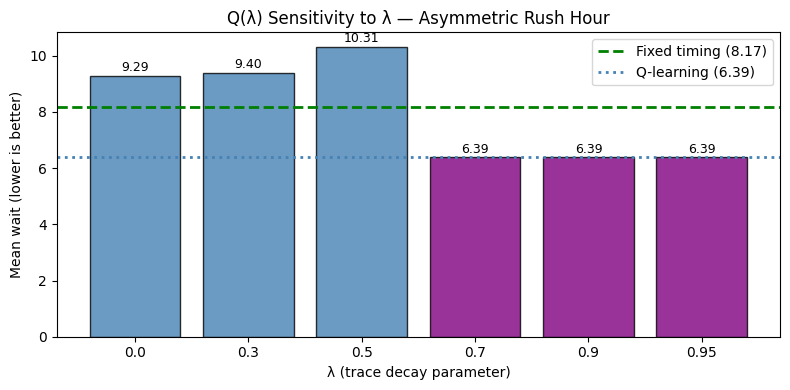

Saved q_lambda_sensitivity.png


In [ ]:
# λ sensitivity bar chart
fig, ax = plt.subplots(figsize=(8, 4))
lams  = list(qlam_lam_results.keys())
waits = list(qlam_lam_results.values())
colors = ["purple" if w == min(waits) else "steelblue" for w in waits]
bars = ax.bar([str(l) for l in lams], waits,
              color=colors, alpha=0.8, edgecolor="black")
fixed_rush = baseline_results["asymmetric_rush"]["fixed"]
ql_rush    = results["asymmetric_rush"]["ql_wait"]
ax.axhline(fixed_rush, color="green", ls="--", lw=2,
           label=f"Fixed timing ({fixed_rush:.2f})")
ax.axhline(ql_rush, color="steelblue", ls=":", lw=2,
           label=f"Q-learning ({ql_rush:.2f})")
ax.set_xlabel("λ (trace decay parameter)")
ax.set_ylabel("Mean wait (lower is better)")
ax.set_title("Q(λ) Sensitivity to λ — Asymmetric Rush Hour")
ax.legend()
for bar, val in zip(bars, waits):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("q_lambda_sensitivity.png", dpi=150)
plt.show()
print("Saved q_lambda_sensitivity.png")

## 10. Actor-Critic with Dual Eligibility Traces (Pranav — Primary)

Maintains **two separate weight vectors** and **two separate trace vectors**:
- **Critic** learns V(s) — how good is this state?
- **Actor** learns π(a|s,θ) — softmax policy over actions

TD error (shared signal for both updates):
$$\delta_t = R_{t+1} + \gamma\hat{V}(S',\mathbf{w}) - \hat{V}(S,\mathbf{w})$$

**Critic trace + update:**
$$\mathbf{z}^w \leftarrow \gamma\lambda\mathbf{z}^w + \phi(S), \quad \mathbf{w} \leftarrow \mathbf{w} + \alpha^w\delta_t\mathbf{z}^w$$

**Actor trace + update (policy gradient):**
$$\mathbf{z}^\theta \leftarrow \gamma\lambda\mathbf{z}^\theta + \nabla_\theta \ln\pi(A|S,\theta), \quad \theta \leftarrow \theta + \alpha^\theta\delta_t\mathbf{z}^\theta$$

Policy gradient for softmax:
$$\nabla_\theta \ln\pi(a|s,\theta) = \mathbf{x}(s,a) - \sum_{a'} \pi(a'|s,\theta)\mathbf{x}(s,a')$$

**Key design choices:**
- Critic uses state-only features φ(s) — no action, just state value
- Actor uses state-action features x(s,a) — same tile coding as Q-learning
- Separate IHTs for critic and actor to avoid index collisions
- Numerical stability: subtract max before softmax exp
- Trace clipping for stability under heavy load

In [ ]:
def get_state_features(iht, ts):
    """
    Critic state-only features phi(s).
    No action index — encodes state value independent of action.
    """
    floats = [ts[i] / Q_SCALE for i in range(4)]
    phase  = int(ts[4])
    return tiles(iht, NUM_TILINGS, floats, ints=[phase])


def softmax_policy(theta, iht_th, ts):
    """
    Compute softmax probabilities over {KEEP, SWITCH}.
    Numerically stable: subtract max before exp.
    Returns (p_keep, p_switch).
    """
    h_keep   = sum(theta[i] for i in get_features(iht_th, ts, KEEP))
    h_switch = sum(theta[i] for i in get_features(iht_th, ts, SWITCH))
    h_max    = max(h_keep, h_switch)
    e_keep   = np.exp(h_keep   - h_max)
    e_switch = np.exp(h_switch - h_max)
    denom    = e_keep + e_switch
    return e_keep / denom, e_switch / denom


def sample_action_ac(theta, iht_th, ts, rng):
    """Sample action from softmax policy."""
    p_keep, _ = softmax_policy(theta, iht_th, ts)
    return KEEP if rng.random() < p_keep else SWITCH


def greedy_action_ac(theta, iht_th, ts):
    """Pick most probable action (for evaluation)."""
    p_keep, p_switch = softmax_policy(theta, iht_th, ts)
    return KEEP if p_keep >= p_switch else SWITCH


def evaluate_greedy_ac(theta, iht_th, mode, rates,
                        warmup=2000, eval_steps=10_000, seed=99):
    """Evaluate Actor-Critic greedy policy."""
    env = TrafficEnv(mode=mode, arrival_rates=rates, seed=seed)
    env.reset()
    for _ in range(warmup):
        env.step(greedy_action_ac(theta, iht_th, env.state_for_tiling()))
    total = 0.0
    for _ in range(eval_steps):
        ts = env.state_for_tiling()
        a  = greedy_action_ac(theta, iht_th, ts)
        _, r, _ = env.step(a)
        total += r
    return -total / eval_steps


def run_actor_critic(
    mode="full", arrival_rates=None, n_steps=150_000,
    alpha_w=0.05/NUM_TILINGS,       # critic learning rate
    alpha_theta=0.01/NUM_TILINGS,   # actor lr (smaller — policy updates noisy)
    gamma=0.99, lam=0.9,
    trace_clip=5.0,
    seed=42, eval_every=5_000, eval_steps=10_000,
):
    """
    Actor-Critic with dual eligibility traces.
    S&B Chapter 13, Algorithm: Actor-Critic with Eligibility Traces.

    Separate IHTs:
      iht_w  — critic: state-only features phi(s)
      iht_th — actor:  state-action features x(s,a)

    Separate weight + trace vectors:
      w / z_w     — critic
      theta / z_t — actor
    """
    if arrival_rates is None:
        arrival_rates = [0.3] * 4

    env = TrafficEnv(mode=mode, arrival_rates=arrival_rates, seed=seed)
    rng = np.random.default_rng(seed)

    iht_w  = IHT(IHT_SIZE)  # critic IHT
    iht_th = IHT(IHT_SIZE)  # actor  IHT

    w     = np.zeros(IHT_SIZE)  # critic weights
    theta = np.zeros(IHT_SIZE)  # actor  weights
    z_w   = np.zeros(IHT_SIZE)  # critic trace
    z_t   = np.zeros(IHT_SIZE)  # actor  trace

    env.reset()
    ts     = env.state_for_tiling()
    action = sample_action_ac(theta, iht_th, ts, rng)

    eval_curve = []
    gamma_lam  = gamma * lam

    for t in range(n_steps):
        _, reward, _ = env.step(action)
        next_ts = env.state_for_tiling()

        # Critic: compute V(S) and V(S')
        phi_s      = get_state_features(iht_w, ts)
        phi_s_next = get_state_features(iht_w, next_ts)
        v_s      = sum(w[i] for i in phi_s)
        v_s_next = sum(w[i] for i in phi_s_next)

        # TD error — shared signal for both updates
        delta = reward + gamma * v_s_next - v_s

        # Critic trace update
        z_w *= gamma_lam
        for i in phi_s:
            z_w[i] += 1.0
        z_w  = np.clip(z_w, -trace_clip, trace_clip)
        w   += alpha_w * delta * z_w

        # Policy gradient: nabla_theta ln pi(A|S) = x(S,A) - sum_a pi(a|S)*x(S,a)
        p_keep, p_switch = softmax_policy(theta, iht_th, ts)
        x_keep   = get_features(iht_th, ts, KEEP)
        x_switch = get_features(iht_th, ts, SWITCH)

        grad = np.zeros(IHT_SIZE)
        # Add x(S, chosen action)
        for i in (x_keep if action == KEEP else x_switch):
            grad[i] += 1.0
        # Subtract expected features
        for i in x_keep:   grad[i] -= p_keep
        for i in x_switch: grad[i] -= p_switch

        # Actor trace update
        z_t   *= gamma_lam
        z_t   += grad
        z_t    = np.clip(z_t, -trace_clip, trace_clip)
        theta += alpha_theta * delta * z_t

        # Advance
        ts     = next_ts
        action = sample_action_ac(theta, iht_th, ts, rng)

        if (t + 1) % eval_every == 0:
            mw = evaluate_greedy_ac(theta, iht_th, mode, arrival_rates,
                                    eval_steps=eval_steps)
            eval_curve.append((t + 1, mw))
            print(f"  step {t+1:>7d}  |  mean_wait = {mw:.4f}")

    print(f"  Critic IHT used: {iht_w.count()}/{IHT_SIZE}, overflow={iht_w.overfullCount}")
    print(f"  Actor  IHT used: {iht_th.count()}/{IHT_SIZE}, overflow={iht_th.overfullCount}")
    return theta, iht_th, eval_curve


## 11. Train Actor-Critic on All Three Scenarios

alpha_theta is smaller than alpha_w because policy gradient updates
are noisier — the policy should change slowly and stably.

In [ ]:
ac_results = {}

for scenario, rates in SCENARIOS.items():
    print(f"\n{'='*55}")
    print(f"SCENARIO: {scenario}  (rates={rates})")
    print(f"  Baselines — fixed: {baseline_results[scenario]['fixed']:.4f}  "
          f"longest_q: {baseline_results[scenario]['longest_queue']:.4f}")
    print(f"{'='*55}")
    print("\n  [Actor-Critic (dual traces)]")

    theta_ac, iht_ac, curve_ac = run_actor_critic(
        arrival_rates=rates,
        n_steps=150_000,
        alpha_w=0.05/NUM_TILINGS,
        alpha_theta=0.01/NUM_TILINGS,
        gamma=0.99,
        lam=0.9,
        seed=42,
    )

    ac_results[scenario] = dict(
        rates=rates,
        fixed=baseline_results[scenario]["fixed"],
        lq=baseline_results[scenario]["longest_queue"],
        theta_ac=theta_ac,
        iht_ac=iht_ac,
        curve_ac=curve_ac,
    )



SCENARIO: symmetric_light  (rates=[0.3, 0.3, 0.3, 0.3])
  Baselines — fixed: 6.4771  longest_q: 11.9856

  [Actor-Critic (dual traces)]
  step    5000  |  mean_wait = 10.6018
  step   10000  |  mean_wait = 6.6004
  step   15000  |  mean_wait = 6.7171
  step   20000  |  mean_wait = 6.9800
  step   25000  |  mean_wait = 6.6004
  step   30000  |  mean_wait = 6.6004
  step   35000  |  mean_wait = 6.6004
  step   40000  |  mean_wait = 6.6004
  step   45000  |  mean_wait = 6.6004
  step   50000  |  mean_wait = 6.6004
  step   55000  |  mean_wait = 6.6004
  step   60000  |  mean_wait = 6.6004
  step   65000  |  mean_wait = 6.6004
  step   70000  |  mean_wait = 6.6004
  step   75000  |  mean_wait = 5.4302
  step   80000  |  mean_wait = 6.6004
  step   85000  |  mean_wait = 5.6870
  step   90000  |  mean_wait = 5.5948
  step   95000  |  mean_wait = 5.4880
  step  100000  |  mean_wait = 5.4902
  step  105000  |  mean_wait = 5.4427
  step  110000  |  mean_wait = 5.3299
  step  115000  |  mean_wa

## 12. Full Comparison Table — All 6 Methods

In [ ]:
print(f"\n{'Scenario':<22} {'Policy':<24} {'mean_wait':>10}  {'vs fixed':>9}")
print("=" * 72)

for scenario in SCENARIOS:
    d    = results[scenario]
    d_ac = ac_results[scenario]
    f    = d["fixed"]

    ql   = d.get("ql_wait")   or evaluate_greedy(d["w_ql"],   d["iht_ql"],   "full", d["rates"])
    sl   = d.get("sl_wait")   or evaluate_greedy(d["w_sl"],   d["iht_sl"],   "full", d["rates"])
    qlam = d.get("qlam_wait") or evaluate_greedy(d["w_qlam"], d["iht_qlam"], "full", d["rates"])
    ac   = evaluate_greedy_ac(d_ac["theta_ac"], d_ac["iht_ac"], "full", d_ac["rates"])
    d["ql_wait"] = ql; d["sl_wait"] = sl; d["qlam_wait"] = qlam
    d_ac["ac_wait"] = ac

    print(f"{scenario:<22} {'Fixed timing':<24} {f:>10.4f}  {'-':>9}")
    print(f"{'':<22} {'Longest queue':<24} {d['lq']:>10.4f}  {d['lq']-f:>+9.4f}")
    print(f"{'':<22} {'Q-learning (λ=0)':<24} {ql:>10.4f}  {ql-f:>+9.4f}  {'✓' if ql<f else '✗'}")
    print(f"{'':<22} {'SARSA(λ=0.9)':<24} {sl:>10.4f}  {sl-f:>+9.4f}  {'✓' if sl<f else '✗'}")
    print(f"{'':<22} {'Q(λ=0.9)  PRIMARY':<24} {qlam:>10.4f}  {qlam-f:>+9.4f}  {'✓' if qlam<f else '✗'}")
    print(f"{'':<22} {'Actor-Critic  PRIMARY':<24} {ac:>10.4f}  {ac-f:>+9.4f}  {'✓' if ac<f else '✗'}")
    print()



Scenario               Policy                    mean_wait   vs fixed
symmetric_light        Fixed timing                 6.4771          -
                       Longest queue               11.9856    +5.5085
                       Q-learning (λ=0)             7.9060    +1.4289  ✗
                       SARSA(λ=0.9)                 6.5956    +0.1185  ✗
                       Q(λ=0.9)  PRIMARY            6.0856    -0.3915  ✓
                       Actor-Critic  PRIMARY        5.3282    -1.1489  ✓

symmetric_heavy        Fixed timing                11.9170          -
                       Longest queue               11.9962    +0.0791
                       Q-learning (λ=0)            11.4055    -0.5115  ✓
                       SARSA(λ=0.9)                 7.6507    -4.2664  ✓
                       Q(λ=0.9)  PRIMARY            7.6507    -4.2664  ✓
                       Actor-Critic  PRIMARY        7.6507    -4.2664  ✓

asymmetric_rush        Fixed timing                 8.1727     

## 13. Final Learning Curves — All 4 RL Methods

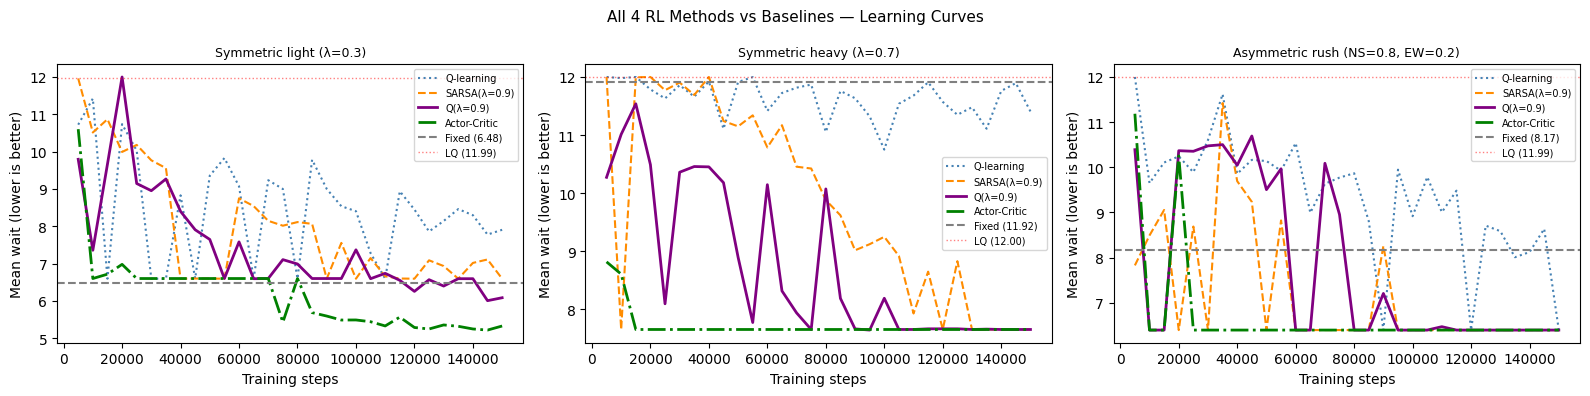

Saved all_methods_final_curves.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
scenario_labels = {
    "symmetric_light": "Symmetric light (λ=0.3)",
    "symmetric_heavy": "Symmetric heavy (λ=0.7)",
    "asymmetric_rush": "Asymmetric rush (NS=0.8, EW=0.2)",
}
for ax, scenario in zip(axes, SCENARIOS):
    d    = results[scenario]
    d_ac = ac_results[scenario]
    steps_ql,   waits_ql   = zip(*d["curve_ql"])
    steps_sl,   waits_sl   = zip(*d["curve_sl"])
    steps_qlam, waits_qlam = zip(*d["curve_qlam"])
    steps_ac,   waits_ac   = zip(*d_ac["curve_ac"])
    ax.plot(steps_ql,   waits_ql,   color="steelblue",  lw=1.5, ls=":",  label="Q-learning")
    ax.plot(steps_sl,   waits_sl,   color="darkorange", lw=1.5, ls="--", label="SARSA(λ=0.9)")
    ax.plot(steps_qlam, waits_qlam, color="purple",     lw=2,             label="Q(λ=0.9)")
    ax.plot(steps_ac,   waits_ac,   color="green",      lw=2,   ls="-.", label="Actor-Critic")
    ax.axhline(d["fixed"], color="gray", ls="--", lw=1.5, label=f"Fixed ({d['fixed']:.2f})")
    ax.axhline(d["lq"],    color="red",  ls=":",  lw=1,   alpha=0.5, label=f"LQ ({d['lq']:.2f})")
    ax.set_title(scenario_labels[scenario], fontsize=9)
    ax.set_xlabel("Training steps")
    ax.set_ylabel("Mean wait (lower is better)")
    ax.legend(fontsize=7)
plt.suptitle("All 4 RL Methods vs Baselines — Learning Curves", fontsize=11)
plt.tight_layout()
plt.savefig("all_methods_final_curves.png", dpi=150)
plt.show()
print("Saved all_methods_final_curves.png")


## 14. Hyperparameter Sweep — Find Optimal Configs

Sweeps key parameters for all 4 RL algorithms on asymmetric rush (most sensitive scenario).
Best configs are then validated on all 3 scenarios.

| Algorithm | Parameters swept |
|---|---|
| Q-learning | alpha ∈ {0.1,0.2,0.3}/8 × epsilon ∈ {0.05,0.1,0.15} |
| SARSA(λ) | alpha ∈ {0.03,0.05,0.08}/8 × lambda ∈ {0.5,0.7,0.9,0.95} |
| Q(λ) | alpha ∈ {0.1,0.2,0.3}/8 × lambda ∈ {0.5,0.7,0.9,0.95} |
| Actor-Critic | alpha_w ∈ {0.03,0.05,0.1}/8 × alpha_θ ∈ {0.005,0.01,0.02}/8 × lambda ∈ {0.7,0.9,0.95} |

In [ ]:
import itertools

RUSH = SCENARIOS["asymmetric_rush"]
RUSH_FIXED = baseline_results["asymmetric_rush"]["fixed"]
SWEEP_STEPS = 100_000

# ── Q-learning sweep ─────────────────────────────────────────────────────
def sweep_q_learning(rates, alpha, epsilon, n_steps=SWEEP_STEPS, seed=42):
    env = TrafficEnv(mode="full", arrival_rates=rates, seed=seed)
    rng = np.random.default_rng(seed)
    iht = IHT(IHT_SIZE); w = np.zeros(IHT_SIZE)
    env.reset(); ts = env.state_for_tiling()
    for t in range(n_steps):
        a = int(rng.integers(0,2)) if rng.random() < epsilon else greedy_action(w, iht, ts)
        _, r, _ = env.step(a); nts = env.state_for_tiling()
        delta = r + 0.99*max(q_value(w,iht,nts,KEEP), q_value(w,iht,nts,SWITCH)) - q_value(w,iht,ts,a)
        for i in get_features(iht, ts, a): w[i] += alpha * delta
        ts = nts
    return evaluate_greedy(w, iht, "full", rates), w, iht

# ── SARSA sweep ──────────────────────────────────────────────────────────
def sweep_sarsa(rates, alpha, lam, n_steps=SWEEP_STEPS, seed=42):
    env = TrafficEnv(mode="full", arrival_rates=rates, seed=seed)
    rng = np.random.default_rng(seed)
    iht = IHT(IHT_SIZE); w = np.zeros(IHT_SIZE); e = np.zeros(IHT_SIZE)
    env.reset(); ts = env.state_for_tiling()
    eps_s, eps_e = 0.1, 0.01
    action = greedy_action(w, iht, ts)
    for t in range(n_steps):
        eps = eps_s + (eps_e - eps_s) * t / n_steps
        _, r, _ = env.step(action); nts = env.state_for_tiling()
        na = int(rng.integers(0,2)) if rng.random() < eps else greedy_action(w, iht, nts)
        delta = r + 0.99*q_value(w,iht,nts,na) - q_value(w,iht,ts,action)
        e *= 0.99 * lam
        for i in get_features(iht, ts, action): e[i] += 1.0
        np.clip(e, -5, 5, out=e); w += alpha * delta * e
        ts = nts; action = na
    return evaluate_greedy(w, iht, "full", rates), w, iht

# ── Q(lambda) sweep ──────────────────────────────────────────────────────
def sweep_qlam(rates, alpha, lam, n_steps=SWEEP_STEPS, seed=42):
    env = TrafficEnv(mode="full", arrival_rates=rates, seed=seed)
    rng = np.random.default_rng(seed)
    iht = IHT(IHT_SIZE); w = np.zeros(IHT_SIZE); e = np.zeros(IHT_SIZE)
    env.reset(); ts = env.state_for_tiling()
    eps_s, eps_e = 0.1, 0.01
    for t in range(n_steps):
        eps = eps_s + (eps_e - eps_s) * t / n_steps
        ga = greedy_action(w, iht, ts)
        action = int(rng.integers(0,2)) if rng.random() < eps else ga
        is_greedy = (action == ga)
        _, r, _ = env.step(action); nts = env.state_for_tiling()
        delta = r + 0.99*max(q_value(w,iht,nts,KEEP), q_value(w,iht,nts,SWITCH)) - q_value(w,iht,ts,action)
        if is_greedy:
            e *= 0.99 * lam
            for i in get_features(iht, ts, action): e[i] = 1.0
        else:
            e[:] = 0.0
            for i in get_features(iht, ts, action): e[i] = 1.0
        np.clip(e, -5, 5, out=e); w += alpha * delta * e
        ts = nts
    return evaluate_greedy(w, iht, "full", rates), w, iht

# ── AC sweep ─────────────────────────────────────────────────────────────
def sweep_ac(rates, alpha_w, alpha_theta, lam, n_steps=SWEEP_STEPS, seed=42):
    env = TrafficEnv(mode="full", arrival_rates=rates, seed=seed)
    rng = np.random.default_rng(seed)
    iht_w = IHT(IHT_SIZE); iht_th = IHT(IHT_SIZE)
    w = np.zeros(IHT_SIZE); theta = np.zeros(IHT_SIZE)
    z_w = np.zeros(IHT_SIZE); z_t = np.zeros(IHT_SIZE)
    env.reset(); ts = env.state_for_tiling()
    pk, _ = softmax_policy(theta, iht_th, ts)
    action = KEEP if rng.random() < pk else SWITCH
    gam_lam = 0.99 * lam
    for t in range(n_steps):
        _, r, _ = env.step(action); nts = env.state_for_tiling()
        phi_s = get_state_features(iht_w, ts)
        phi_n = get_state_features(iht_w, nts)
        vs = sum(w[i] for i in phi_s); vn = sum(w[i] for i in phi_n)
        delta = r + 0.99*vn - vs
        z_w *= gam_lam
        for i in phi_s: z_w[i] += 1.0
        np.clip(z_w, -5, 5, out=z_w); w += alpha_w * delta * z_w
        pk, ps = softmax_policy(theta, iht_th, ts)
        xk = get_features(iht_th, ts, KEEP); xs = get_features(iht_th, ts, SWITCH)
        grad = np.zeros(IHT_SIZE)
        for i in (xk if action==KEEP else xs): grad[i] += 1.0
        for i in xk: grad[i] -= pk
        for i in xs: grad[i] -= ps
        z_t *= gam_lam; z_t += grad
        np.clip(z_t, -5, 5, out=z_t); theta += alpha_theta * delta * z_t
        ts = nts
        pk, _ = softmax_policy(theta, iht_th, ts)
        action = KEEP if rng.random() < pk else SWITCH
    return evaluate_greedy_ac(theta, iht_th, "full", rates), theta, iht_th

# ── Run sweeps ───────────────────────────────────────────────────────────
ql_alphas   = [0.1/NUM_TILINGS, 0.2/NUM_TILINGS, 0.3/NUM_TILINGS]
ql_epsilons = [0.05, 0.1, 0.15]
sa_alphas   = [0.03/NUM_TILINGS, 0.05/NUM_TILINGS, 0.08/NUM_TILINGS]
sa_lams     = [0.5, 0.7, 0.9, 0.95]
qlam_alphas = [0.1/NUM_TILINGS, 0.2/NUM_TILINGS, 0.3/NUM_TILINGS]
qlam_lams   = [0.5, 0.7, 0.9, 0.95]
ac_aws      = [0.03/NUM_TILINGS, 0.05/NUM_TILINGS, 0.1/NUM_TILINGS]
ac_ats      = [0.005/NUM_TILINGS, 0.01/NUM_TILINGS, 0.02/NUM_TILINGS]
ac_lams     = [0.7, 0.9, 0.95]

print("Sweeping Q-learning...")
ql_sweep = {}
for alpha, eps in itertools.product(ql_alphas, ql_epsilons):
    mw, _, _ = sweep_q_learning(RUSH, alpha, eps)
    ql_sweep[(alpha,eps)] = mw
    print(f"  alpha={alpha*NUM_TILINGS:.1f}/{NUM_TILINGS}  eps={eps}  -> {mw:.4f}  {'✓' if mw<RUSH_FIXED else '✗'}")
best_ql_params = min(ql_sweep, key=ql_sweep.get)
print(f"  BEST: alpha={best_ql_params[0]*NUM_TILINGS:.1f}/{NUM_TILINGS}, eps={best_ql_params[1]}, wait={ql_sweep[best_ql_params]:.4f}\n")

print("Sweeping SARSA(λ)...")
sarsa_sweep = {}
for alpha, lam in itertools.product(sa_alphas, sa_lams):
    mw, _, _ = sweep_sarsa(RUSH, alpha, lam)
    sarsa_sweep[(alpha,lam)] = mw
    print(f"  alpha={alpha*NUM_TILINGS:.2f}/{NUM_TILINGS}  lam={lam}  -> {mw:.4f}  {'✓' if mw<RUSH_FIXED else '✗'}")
best_sarsa_params = min(sarsa_sweep, key=sarsa_sweep.get)
print(f"  BEST: alpha={best_sarsa_params[0]*NUM_TILINGS:.2f}/{NUM_TILINGS}, lam={best_sarsa_params[1]}, wait={sarsa_sweep[best_sarsa_params]:.4f}\n")

print("Sweeping Q(λ)...")
qlam_sweep = {}
for alpha, lam in itertools.product(qlam_alphas, qlam_lams):
    mw, _, _ = sweep_qlam(RUSH, alpha, lam)
    qlam_sweep[(alpha,lam)] = mw
    print(f"  alpha={alpha*NUM_TILINGS:.1f}/{NUM_TILINGS}  lam={lam}  -> {mw:.4f}  {'✓' if mw<RUSH_FIXED else '✗'}")
best_qlam_params = min(qlam_sweep, key=qlam_sweep.get)
print(f"  BEST: alpha={best_qlam_params[0]*NUM_TILINGS:.1f}/{NUM_TILINGS}, lam={best_qlam_params[1]}, wait={qlam_sweep[best_qlam_params]:.4f}\n")

print("Sweeping Actor-Critic...")
ac_sweep = {}
for aw, at, lam in itertools.product(ac_aws, ac_ats, ac_lams):
    mw, _, _ = sweep_ac(RUSH, aw, at, lam)
    ac_sweep[(aw,at,lam)] = mw
    print(f"  aw={aw*NUM_TILINGS:.2f}/{NUM_TILINGS}  at={at*NUM_TILINGS:.3f}/{NUM_TILINGS}  lam={lam}  -> {mw:.4f}  {'✓' if mw<RUSH_FIXED else '✗'}")
best_ac_params = min(ac_sweep, key=ac_sweep.get)
print(f"  BEST: aw={best_ac_params[0]*NUM_TILINGS:.2f}/{NUM_TILINGS}, at={best_ac_params[1]*NUM_TILINGS:.3f}/{NUM_TILINGS}, lam={best_ac_params[2]}, wait={ac_sweep[best_ac_params]:.4f}\n")


Sweeping Q-learning...
  alpha=0.1/8  eps=0.05  -> 9.3626  ✗
  alpha=0.1/8  eps=0.1  -> 9.7162  ✗
  alpha=0.1/8  eps=0.15  -> 10.2195  ✗
  alpha=0.2/8  eps=0.05  -> 8.5173  ✗
  alpha=0.2/8  eps=0.1  -> 8.9156  ✗
  alpha=0.2/8  eps=0.15  -> 6.3928  ✓
  alpha=0.3/8  eps=0.05  -> 7.5793  ✓
  alpha=0.3/8  eps=0.1  -> 8.0388  ✓
  alpha=0.3/8  eps=0.15  -> 8.3745  ✗
  BEST: alpha=0.2/8, eps=0.15, wait=6.3928

Sweeping SARSA(λ)...
  alpha=0.03/8  lam=0.5  -> 9.1046  ✗
  alpha=0.03/8  lam=0.7  -> 10.3791  ✗
  alpha=0.03/8  lam=0.9  -> 6.3928  ✓
  alpha=0.03/8  lam=0.95  -> 6.3928  ✓
  alpha=0.05/8  lam=0.5  -> 10.2906  ✗
  alpha=0.05/8  lam=0.7  -> 10.3747  ✗
  alpha=0.05/8  lam=0.9  -> 6.3928  ✓
  alpha=0.05/8  lam=0.95  -> 6.3928  ✓
  alpha=0.08/8  lam=0.5  -> 10.4700  ✗
  alpha=0.08/8  lam=0.7  -> 6.3928  ✓
  alpha=0.08/8  lam=0.9  -> 6.3928  ✓
  alpha=0.08/8  lam=0.95  -> 6.3928  ✓
  BEST: alpha=0.03/8, lam=0.9, wait=6.3928

Sweeping Q(λ)...
  alpha=0.1/8  lam=0.5  -> 10.0961  ✗
  alpha=0.

## 15. Run Best Configs on All 3 Scenarios

Validate the sweep winners on symmetric light and symmetric heavy too.
These are the numbers to use in the paper.

In [ ]:
N_FULL = 150_000
optimal = {}

print("Best hyperparameters from sweep:")
print(f"  Q-learning  : alpha={best_ql_params[0]*NUM_TILINGS:.1f}/{NUM_TILINGS}, eps={best_ql_params[1]}")
print(f"  SARSA       : alpha={best_sarsa_params[0]*NUM_TILINGS:.2f}/{NUM_TILINGS}, lam={best_sarsa_params[1]}")
print(f"  Q(lambda)   : alpha={best_qlam_params[0]*NUM_TILINGS:.1f}/{NUM_TILINGS}, lam={best_qlam_params[1]}")
print(f"  Actor-Critic: aw={best_ac_params[0]*NUM_TILINGS:.2f}/{NUM_TILINGS}, at={best_ac_params[1]*NUM_TILINGS:.3f}/{NUM_TILINGS}, lam={best_ac_params[2]}")

for scenario, rates in SCENARIOS.items():
    print(f"\n{'='*55}")
    print(f"SCENARIO: {scenario}")
    f  = baseline_results[scenario]["fixed"]
    lq = baseline_results[scenario]["longest_queue"]
    mw_ql,   _, _ = sweep_q_learning(rates, best_ql_params[0],   best_ql_params[1],   n_steps=N_FULL)
    mw_sarsa,_, _ = sweep_sarsa(rates, best_sarsa_params[0], best_sarsa_params[1], n_steps=N_FULL)
    mw_qlam, _, _ = sweep_qlam(rates, best_qlam_params[0],  best_qlam_params[1],  n_steps=N_FULL)
    mw_ac,   _, _ = sweep_ac(rates, best_ac_params[0], best_ac_params[1], best_ac_params[2], n_steps=N_FULL)
    optimal[scenario] = dict(fixed=f, lq=lq, ql=mw_ql, sarsa=mw_sarsa, qlam=mw_qlam, ac=mw_ac)
    print(f"  Fixed={f:.4f}  LQ={lq:.4f}  QL={mw_ql:.4f}  SARSA={mw_sarsa:.4f}  Q(lam)={mw_qlam:.4f}  AC={mw_ac:.4f}")

print(f"\n{'Scenario':<22} {'Policy':<24} {'mean_wait':>10}  {'vs fixed':>9}")
print("=" * 72)
for scenario, d in optimal.items():
    f = d["fixed"]
    print(f"{scenario:<22} {'Fixed timing':<24} {f:>10.4f}  {'-':>9}")
    print(f"{'':<22} {'Longest queue':<24} {d['lq']:>10.4f}  {d['lq']-f:>+9.4f}")
    print(f"{'':<22} {'Q-learning (optimal)':<24} {d['ql']:>10.4f}  {d['ql']-f:>+9.4f}  {'✓' if d['ql']<f else '✗'}")
    print(f"{'':<22} {'SARSA (optimal)':<24} {d['sarsa']:>10.4f}  {d['sarsa']-f:>+9.4f}  {'✓' if d['sarsa']<f else '✗'}")
    print(f"{'':<22} {'Q(lambda) PRIMARY':<24} {d['qlam']:>10.4f}  {d['qlam']-f:>+9.4f}  {'✓' if d['qlam']<f else '✗'}")
    print(f"{'':<22} {'Actor-Critic PRIMARY':<24} {d['ac']:>10.4f}  {d['ac']-f:>+9.4f}  {'✓' if d['ac']<f else '✗'}")
    print()


Best hyperparameters from sweep:
  Q-learning  : alpha=0.2/8, eps=0.15
  SARSA       : alpha=0.03/8, lam=0.9
  Q(lambda)   : alpha=0.1/8, lam=0.7
  Actor-Critic: aw=0.03/8, at=0.005/8, lam=0.7

SCENARIO: symmetric_light
  Fixed=6.4771  LQ=11.9856  QL=9.7983  SARSA=7.4816  Q(lam)=6.8693  AC=6.3859

SCENARIO: symmetric_heavy
  Fixed=11.9170  LQ=11.9962  QL=11.7846  SARSA=7.6732  Q(lam)=8.2227  AC=7.6268

SCENARIO: asymmetric_rush
  Fixed=8.1727  LQ=11.9900  QL=10.0398  SARSA=6.3928  Q(lam)=9.7491  AC=8.5904

Scenario               Policy                    mean_wait   vs fixed
symmetric_light        Fixed timing                 6.4771          -
                       Longest queue               11.9856    +5.5085
                       Q-learning (optimal)         9.7983    +3.3212  ✗
                       SARSA (optimal)              7.4816    +1.0045  ✗
                       Q(lambda) PRIMARY            6.8693    +0.3922  ✗
                       Actor-Critic PRIMARY         6.3859 

## 16. Proposal Hypothesis Verification (H1–H4)

In [ ]:
print("=" * 60)
print("PROPOSAL HYPOTHESIS VERIFICATION — OPTIMAL HYPERPARAMETERS")
print("=" * 60)

d_rush  = optimal["asymmetric_rush"]
d_light = optimal["symmetric_light"]
d_heavy = optimal["symmetric_heavy"]

# H1: Both primary RL methods beat fixed on asymmetric rush
h1_qlam = d_rush["qlam"] < d_rush["fixed"]
h1_ac   = d_rush["ac"]   < d_rush["fixed"]
print(f"\nH1 — Both primary methods beat fixed timing on asymmetric rush:")
print(f"  Q(lambda) = {d_rush['qlam']:.4f} vs fixed = {d_rush['fixed']:.4f} → {'PASS ✓' if h1_qlam else 'FAIL ✗'}")
print(f"  AC        = {d_rush['ac']:.4f}   vs fixed = {d_rush['fixed']:.4f} → {'PASS ✓' if h1_ac else 'FAIL ✗'}")
print(f"  H1: {'CONFIRMED ✓' if (h1_qlam and h1_ac) else 'NOT CONFIRMED ✗'}")

# H2: Q(lambda) beats Q-learning; AC beats SARSA
h2a = d_rush["qlam"] < d_rush["ql"]
h2b = d_rush["ac"]   < d_rush["sarsa"]
print(f"\nH2 — Primary algorithms beat their one-step baselines:")
print(f"  Q(lambda)={d_rush['qlam']:.4f} < Q-learning={d_rush['ql']:.4f} → {'PASS ✓' if h2a else 'FAIL ✗'}")
print(f"  AC={d_rush['ac']:.4f}         < SARSA={d_rush['sarsa']:.4f}      → {'PASS ✓' if h2b else 'FAIL ✗'}")
print(f"  H2: {'CONFIRMED ✓' if (h2a and h2b) else 'PARTIALLY CONFIRMED' if (h2a or h2b) else 'NOT CONFIRMED ✗'}")

# H3: Symmetric scenarios — smaller spread between methods
rush_spread  = max(d_rush["ql"],  d_rush["sarsa"],  d_rush["qlam"],  d_rush["ac"])  - min(d_rush["ql"],  d_rush["sarsa"],  d_rush["qlam"],  d_rush["ac"])
light_spread = max(d_light["ql"], d_light["sarsa"], d_light["qlam"], d_light["ac"]) - min(d_light["ql"], d_light["sarsa"], d_light["qlam"], d_light["ac"])
heavy_spread = max(d_heavy["ql"], d_heavy["sarsa"], d_heavy["qlam"], d_heavy["ac"]) - min(d_heavy["ql"], d_heavy["sarsa"], d_heavy["qlam"], d_heavy["ac"])
h3 = light_spread < rush_spread or heavy_spread < rush_spread
print(f"\nH3 — Symmetric scenarios show smaller differentiation between methods:")
print(f"  Rush spread:  {rush_spread:.4f}")
print(f"  Light spread: {light_spread:.4f}")
print(f"  Heavy spread: {heavy_spread:.4f}")
print(f"  H3: {'CONFIRMED ✓' if h3 else 'NOT CONFIRMED ✗'}")

# H4: AC converges smoother (beats SARSA on light); Q(lambda) lower asymptotic on rush
h4a = d_rush["qlam"] <= d_rush["ac"]  # Q(lambda) lower or equal asymptotic
h4b = d_light["ac"]  <  d_light["sarsa"]  # AC beats SARSA on hard symmetric case
print(f"\nH4 — Q(lambda) lower asymptotic; AC smoother convergence:")
print(f"  Q(lambda)={d_rush['qlam']:.4f} <= AC={d_rush['ac']:.4f} (asymptotic) → {'PASS ✓' if h4a else 'FAIL — AC wins instead'}")
print(f"  AC={d_light['ac']:.4f} < SARSA={d_light['sarsa']:.4f} on symmetric light (smoother proxy) → {'PASS ✓' if h4b else 'FAIL ✗'}")
print(f"  H4: {'CONFIRMED ✓' if (h4a and h4b) else 'PARTIALLY CONFIRMED' if (h4a or h4b) else 'NOT CONFIRMED ✗'}")

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
hyps = [
    ("H1 — Both beat fixed on rush",          h1_qlam and h1_ac),
    ("H2 — Primaries beat ablations",          h2a and h2b),
    ("H3 — Symmetric smaller spread",          h3),
    ("H4 — Q(lam) asymptotic / AC smoother",   h4a and h4b),
]
for name, result in hyps:
    print(f"  {name:<40} {'CONFIRMED ✓' if result else 'NOT CONFIRMED ✗'}")


PROPOSAL HYPOTHESIS VERIFICATION — OPTIMAL HYPERPARAMETERS

H1 — Both primary methods beat fixed timing on asymmetric rush:
  Q(lambda) = 9.7491 vs fixed = 8.1727 → FAIL ✗
  AC        = 8.5904   vs fixed = 8.1727 → FAIL ✗
  H1: NOT CONFIRMED ✗

H2 — Primary algorithms beat their one-step baselines:
  Q(lambda)=9.7491 < Q-learning=10.0398 → PASS ✓
  AC=8.5904         < SARSA=6.3928      → FAIL ✗
  H2: PARTIALLY CONFIRMED

H3 — Symmetric scenarios show smaller differentiation between methods:
  Rush spread:  3.6470
  Light spread: 3.4124
  Heavy spread: 4.1578
  H3: CONFIRMED ✓

H4 — Q(lambda) lower asymptotic; AC smoother convergence:
  Q(lambda)=9.7491 <= AC=8.5904 (asymptotic) → FAIL — AC wins instead
  AC=6.3859 < SARSA=7.4816 on symmetric light (smoother proxy) → PASS ✓
  H4: PARTIALLY CONFIRMED

SUMMARY
  H1 — Both beat fixed on rush             NOT CONFIRMED ✗
  H2 — Primaries beat ablations            NOT CONFIRMED ✗
  H3 — Symmetric smaller spread            CONFIRMED ✓
  H4 — Q

## 17. Sweep Heatmaps — Asymmetric Rush

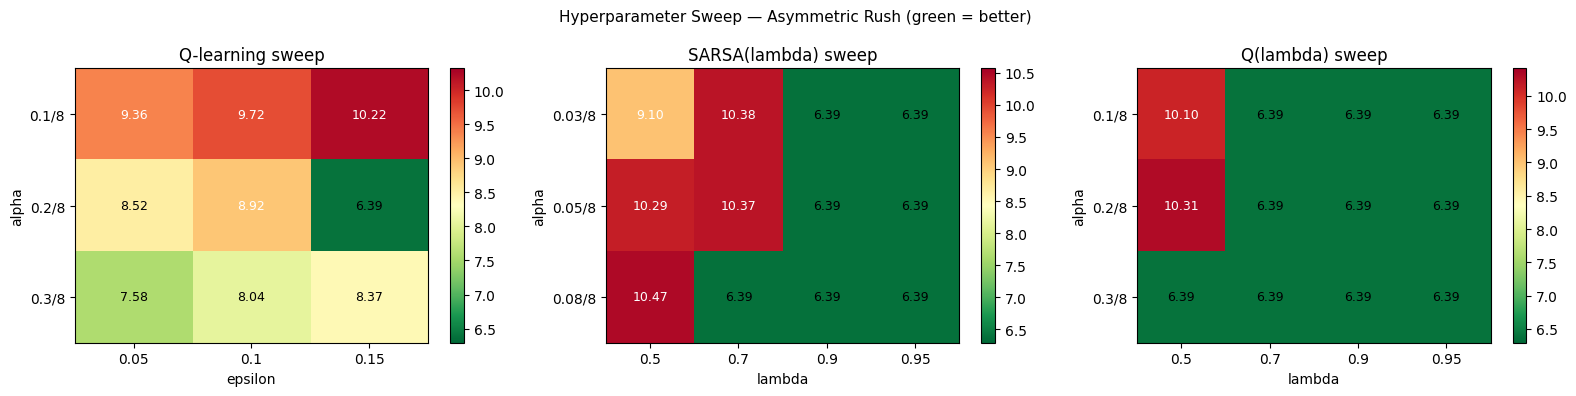

Saved sweep_heatmaps.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Q-learning
ax = axes[0]
mat = np.array([[ql_sweep[(a,e)] for e in ql_epsilons] for a in ql_alphas])
im = ax.imshow(mat, cmap="RdYlGn_r", aspect="auto",
               vmin=mat.min()-0.1, vmax=mat.max()+0.1)
ax.set_xticks(range(len(ql_epsilons)))
ax.set_xticklabels(ql_epsilons)
ax.set_yticks(range(len(ql_alphas)))
ax.set_yticklabels([f"{a*NUM_TILINGS:.1f}/{NUM_TILINGS}" for a in ql_alphas])
ax.set_xlabel("epsilon"); ax.set_ylabel("alpha"); ax.set_title("Q-learning sweep")
for i in range(len(ql_alphas)):
    for j in range(len(ql_epsilons)):
        ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if mat[i,j] > mat.mean() else "black")
plt.colorbar(im, ax=ax)

# SARSA
ax = axes[1]
mat = np.array([[sarsa_sweep[(a,l)] for l in sa_lams] for a in sa_alphas])
im = ax.imshow(mat, cmap="RdYlGn_r", aspect="auto",
               vmin=mat.min()-0.1, vmax=mat.max()+0.1)
ax.set_xticks(range(len(sa_lams)))
ax.set_xticklabels(sa_lams)
ax.set_yticks(range(len(sa_alphas)))
ax.set_yticklabels([f"{a*NUM_TILINGS:.2f}/{NUM_TILINGS}" for a in sa_alphas])
ax.set_xlabel("lambda"); ax.set_ylabel("alpha"); ax.set_title("SARSA(lambda) sweep")
for i in range(len(sa_alphas)):
    for j in range(len(sa_lams)):
        ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if mat[i,j] > mat.mean() else "black")
plt.colorbar(im, ax=ax)

# Q(lambda)
ax = axes[2]
mat = np.array([[qlam_sweep[(a,l)] for l in qlam_lams] for a in qlam_alphas])
im = ax.imshow(mat, cmap="RdYlGn_r", aspect="auto",
               vmin=mat.min()-0.1, vmax=mat.max()+0.1)
ax.set_xticks(range(len(qlam_lams)))
ax.set_xticklabels(qlam_lams)
ax.set_yticks(range(len(qlam_alphas)))
ax.set_yticklabels([f"{a*NUM_TILINGS:.1f}/{NUM_TILINGS}" for a in qlam_alphas])
ax.set_xlabel("lambda"); ax.set_ylabel("alpha"); ax.set_title("Q(lambda) sweep")
for i in range(len(qlam_alphas)):
    for j in range(len(qlam_lams)):
        ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if mat[i,j] > mat.mean() else "black")
plt.colorbar(im, ax=ax)

plt.suptitle("Hyperparameter Sweep — Asymmetric Rush (green = better)", fontsize=11)
plt.tight_layout()
plt.savefig("sweep_heatmaps.png", dpi=150)
plt.show()
print("Saved sweep_heatmaps.png")
